Base-case output = 8.4675

 x1 | Lower effect = -0.2350 | Upper effect = -0.1328
 x2 | Lower effect = -2.0085 | Upper effect = -1.1772
 x3 | Lower effect = -0.4052 | Upper effect = 1.0910


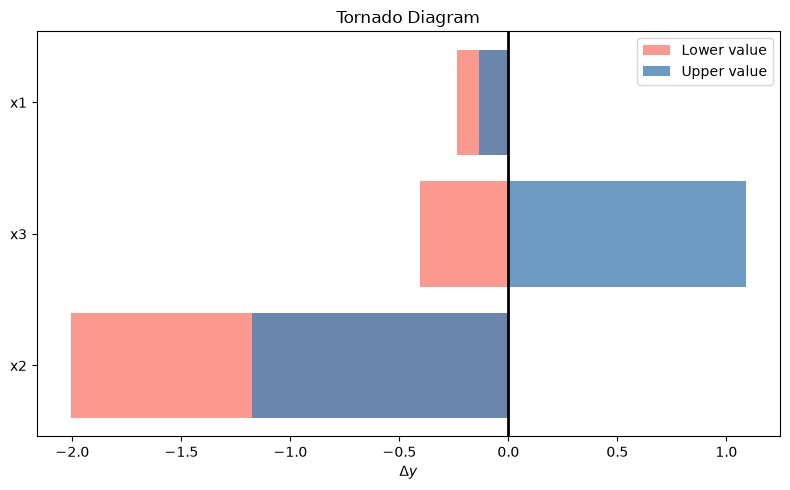

In [27]:
import numpy as np
import matplotlib.pyplot as plt

# ==========================================================
# MODEL
# ==========================================================

def model(x):
    #Ishigami function
    a = 7
    b = 0.1
    return (np.sin(x[0])+ a * np.sin(x[1]) ** 2+b * x[2] ** 4 * np.sin(x[0]))


# ==========================================================
# TORNADO ANALYSIS
# ==========================================================

def tornado_analysis(model, x0, x_low, x_high):

    y0 = model(x0)

    n = len(x0)

    delta_minus = np.zeros(n)
    delta_plus = np.zeros(n)

    for i in range(n):

        # Equation (3.12)
        x = x0.copy()
        x[i] = x_high[i]
        y_plus = model(x)

        # Equation (3.13)
        delta_plus[i] = y_plus - y0

        # Equation (3.14)
        x = x0.copy()
        x[i] = x_low[i]
        y_minus = model(x)

        # Equation (3.15)
        delta_minus[i] = y_minus - y0

    return y0, delta_minus, delta_plus

#======================================================
#TORNADO PLOT CLASSICAL

#======================================================

def plot_tornado(names, delta_minus, delta_plus):

    impact = np.maximum(
        np.abs(delta_minus),
        np.abs(delta_plus)
    )

    idx = np.argsort(impact)[::-1]

    names = [names[i] for i in idx]
    delta_minus = delta_minus[idx]
    delta_plus = delta_plus[idx]

    y = np.arange(len(names))

    fig, ax = plt.subplots(figsize=(8,5))

    ax.barh(
        y,
        delta_minus,
        color='salmon',
        alpha=0.8,
        label='Lower value'
    )

    ax.barh(
        y,
        delta_plus,
        color='steelblue',
        alpha=0.8,
        label='Upper value'
    )

    ax.axvline(0,color='black',linewidth=2)

    ax.set_yticks(y)
    ax.set_yticklabels(names)

    ax.set_xlabel(r'$\Delta y$')
    ax.set_title('Tornado Diagram')

    ax.legend()

    plt.tight_layout()
    plt.show()


# ==========================================================
# TORNADO PLOT NOT OVERLAPPED (NOT CLASSIC)
# ==========================================================

def plot_tornado_classical(names, delta_minus, delta_plus):

    import numpy as np
    import matplotlib.pyplot as plt

    # Outputs corresponding to low/high values
    low_vals = delta_minus.copy()
    high_vals = delta_plus.copy()

    # Rank by total range
    widths = np.abs(high_vals - low_vals)
    idx = np.argsort(widths)[::-1]

    names = [names[i] for i in idx]
    low_vals = low_vals[idx]
    high_vals = high_vals[idx]

    y = np.arange(len(names))

    fig, ax = plt.subplots(figsize=(8,5))

    for i in range(len(names)):

        # Sort the two effects
        left = min(low_vals[i], high_vals[i])
        right = max(low_vals[i], high_vals[i])

        # Draw the larger bar first
        ax.barh(
            y[i],
            right,
            color="steelblue",
            alpha=0.8
        )

        ax.barh(
            y[i],
            left,
            color="salmon",
            alpha=0.8
        )

    ax.axvline(0, color="black", linewidth=2)

    ax.set_yticks(y)
    ax.set_yticklabels(names)

    ax.set_xlabel(r"$\Delta y$")
    ax.set_title("Classical Tornado Diagram")

    from matplotlib.patches import Patch
    ax.legend(handles=[
        Patch(color="salmon", label="Lower value"),
        Patch(color="steelblue", label="Upper value")
    ])

    plt.tight_layout()
    plt.show()


# ==========================================================
# INPUT DEFINITION
# ==========================================================

# Base-case values
x0 = np.array([1.5, 1.5, 1.5])
# Lower values
x_low = np.array([1,1,1])
# Upper values
x_high = np.array([2,2,2])

#x_high = np.array([
#    np.pi,
#    np.pi,
#    np.pi
#])


# Lower values
#x_low = np.array([
#    -np.pi,
#    -np.pi,
#    -np.pi
#])

# Upper values
#x_high = np.array([
#    np.pi,
#    np.pi,
#    np.pi
#])

variable_names = ["x1", "x2", "x3"]


# ==========================================================
# RUN
# ==========================================================

y0, delta_minus, delta_plus = tornado_analysis(model,x0,x_low,x_high)

print(f"Base-case output = {y0:.4f}\n")

for i, name in enumerate(variable_names):
    print(
        f"{name:>3} | "
        f"Lower effect = {delta_minus[i]:.4f} | "
        f"Upper effect = {delta_plus[i]:.4f}"
    )

plot_tornado(
    variable_names,
    delta_minus,
    delta_plus
)

In [28]:
print("y0 =", y0)

for i in range(len(variable_names)):
    print(
        variable_names[i],
        y0 + delta_minus[i],
        y0 + delta_plus[i]
    )

y0 = 8.467450561673916
x1 8.232439408968453 8.334602987257743
x2 6.458990751487355 7.290229496594999
x3 8.062218223366019 9.5584607032721


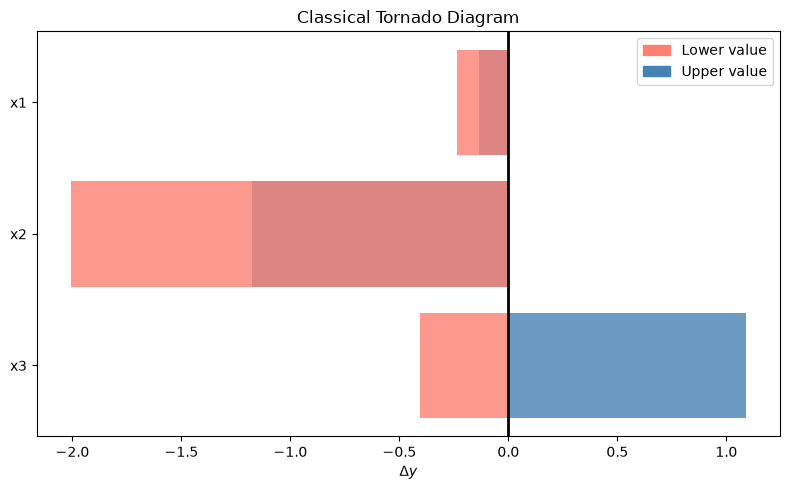

In [29]:
plot_tornado_classical(variable_names, delta_minus, delta_plus)